<a href="https://colab.research.google.com/github/Viera1624/TelecomX_LATAM/blob/main/telecomx_latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Trello del desafío](https://trello.com/b/Va6JwjjL/telecomxlatam)

#📌 Extracción

In [57]:
import pandas as pd

In [58]:
datos_clientes = pd.read_json('/content/TelecomX_Data.json')
datos_clientes.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Normalizando Json

In [59]:
def normalizar_json(columna):
  df_norm = pd.json_normalize(datos_clientes[columna])

  return df_norm

customer = normalizar_json('customer')
phone = normalizar_json('phone')
internet = normalizar_json('internet')
account = normalizar_json('account')


In [60]:
datos_clientes_norm = pd.concat([datos_clientes[['customerID', 'Churn']],
                                 customer, phone, internet, account],
                                axis=1)
datos_clientes_norm

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

##Verificando si hay valores nulos, duplicados o errores de formato

In [61]:
datos_clientes_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [62]:
datos_clientes_norm.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


Los IDs de cliente son valores únicos, por lo que no debería haber un ID presente más de una vez en nuestros registros

In [63]:
x =datos_clientes_norm['customerID'].unique()

In [64]:
len(x)

7267

##Normalizando las columnaas

###Renombrar las columnaas

In [65]:
columnas = list(datos_clientes_norm.columns)

columnas_nuevas = ['ID_Cliente','Retirado','Genero','Mayor_65_Años','Tiene_Pareja','Dependientes',
                    'Meses_De_Contrato','Servicio_Telefonico','Multiples_Lineas','Servicio_Internet','Seguridad_En_linea',
                    'Respaldo_En_linea','Proteccion_Del_Dispositivo','Soporte_Tecnico','Television_Por_Cable','Streaming_Peliculas',
                    'Tipo_De_Contrato', 'Factura_En_Linea','Metodo_De_Pago', 'Total_Por_Mes',
                    'Total_Gastado']

renombrar = dict(zip(columnas,columnas_nuevas))

In [66]:
datos_clientes_norm.rename(columns=renombrar, inplace=True)
datos_clientes_norm.head(1)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3


##Transformando datos numéricos

Alintentar transformar el tipo de datos de la columna Total_Gastado a float encontramos que hay espacios entre los registros, vamos a verificar

In [67]:
datos_clientes_norm[datos_clientes_norm['Total_Gastado'].str.contains('\ ', na= False)]

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-4215343052.py:1: SyntaxWarning: invalid escape sequence '\ '
  datos_clientes_norm[datos_clientes_norm['Total_Gastado'].str.contains('\ ', na= False)]


,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


Una vez encontrados los registros que tienen espacios, podemos observar que coinciden con el numero 0(cero) en la columna Meses_De_Contrato, esto puede indicar que son clientes nuevos y por lo tanto, no han acumulado un cargo total. Vamos a verificar si hay más clientes nuevos

In [68]:
datos_clientes_norm.query('Meses_De_Contrato == 0')

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


los resultados obtenidos coinciden con ceros en la columna Meses_De_Contrato y espacios en Total_Gastado, procedemos entonces a reemplazar espacios por ceros y realizar la respectiva transformación

In [69]:
datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].replace('\ ', '0', regex=True)


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3318985259.py:1: SyntaxWarning: invalid escape sequence '\ '
  datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].replace('\ ', '0', regex=True)


In [70]:
import numpy as np
datos_clientes_norm['Total_Gastado']= datos_clientes_norm['Total_Gastado'].astype(np.float64)

Ahora, tenemos una serie de columnas con valores de "Yes" y "No", pero para este análisis nos resultaría más fácil trabajar con 0 para "No" y 1 para "Yes", así que vamos a reemplazar estos valores creando una lista con dichas columnas que queremos transformar de str a int64

In [71]:
transformar = ['Retirado','Tiene_Pareja','Dependientes',
               'Servicio_Telefonico','Multiples_Lineas','Seguridad_En_linea',
               'Respaldo_En_linea','Proteccion_Del_Dispositivo','Soporte_Tecnico','Television_Por_Cable','Streaming_Peliculas',
               'Factura_En_Linea']

Verificamos los valores únicos en las columnasde nuestra lista para identificar las posibles complicaciones (Valores distintos a "Yes" o "No") al momento de realizar la transformación

In [72]:
for columna in datos_clientes_norm[transformar]:
    print(f"Valores unicos para la columna '{columna}':")
    print(datos_clientes_norm[columna].unique())
    print("\n")

Valores unicos para la columna 'Retirado':
['No' 'Yes' '']


Valores unicos para la columna 'Tiene_Pareja':
['Yes' 'No']


Valores unicos para la columna 'Dependientes':
['Yes' 'No']


Valores unicos para la columna 'Servicio_Telefonico':
['Yes' 'No']


Valores unicos para la columna 'Multiples_Lineas':
['No' 'Yes' 'No phone service']


Valores unicos para la columna 'Seguridad_En_linea':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Respaldo_En_linea':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Proteccion_Del_Dispositivo':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Soporte_Tecnico':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Television_Por_Cable':
['Yes' 'No' 'No internet service']


Valores unicos para la columna 'Streaming_Peliculas':
['No' 'Yes' 'No internet service']


Valores unicos para la columna 'Factura_En_Linea':
['Yes' 'No']




Como podemos observar, hay columnas que tienen cadenas vacías (''), entre otras como 'No internet service' y 'No phone service', tenemos que reemplazar también estos valores por 0 para poder realizar nuestra transformación

In [73]:
#Creamos un diccionario con los valores a reemplazar
reemplazar = {'': '0', 'No phone service': '0', 'No internet service': '0', 'Yes': '1', 'No': '0'}

#Reemplazamos los valores con un replace() dentro de un lazo for
for columna in datos_clientes_norm[transformar]:
  datos_clientes_norm[transformar] = datos_clientes_norm[transformar].replace(reemplazar)


In [74]:
for columna in datos_clientes_norm[transformar]:
    print(f"Valores unicos para la columna '{columna}':")
    print(datos_clientes_norm[columna].unique())
    print("\n")

Valores unicos para la columna 'Retirado':
['0' '1']


Valores unicos para la columna 'Tiene_Pareja':
['1' '0']


Valores unicos para la columna 'Dependientes':
['1' '0']


Valores unicos para la columna 'Servicio_Telefonico':
['1' '0']


Valores unicos para la columna 'Multiples_Lineas':
['0' '1']


Valores unicos para la columna 'Seguridad_En_linea':
['0' '1']


Valores unicos para la columna 'Respaldo_En_linea':
['1' '0']


Valores unicos para la columna 'Proteccion_Del_Dispositivo':
['0' '1']


Valores unicos para la columna 'Soporte_Tecnico':
['1' '0']


Valores unicos para la columna 'Television_Por_Cable':
['1' '0']


Valores unicos para la columna 'Streaming_Peliculas':
['0' '1']


Valores unicos para la columna 'Factura_En_Linea':
['1' '0']




In [75]:
datos_clientes_norm[transformar] = datos_clientes_norm[transformar].astype(np.int64)

In [76]:
datos_clientes_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_Cliente                  7267 non-null   object 
 1   Retirado                    7267 non-null   int64  
 2   Genero                      7267 non-null   object 
 3   Mayor_65_Años               7267 non-null   int64  
 4   Tiene_Pareja                7267 non-null   int64  
 5   Dependientes                7267 non-null   int64  
 6   Meses_De_Contrato           7267 non-null   int64  
 7   Servicio_Telefonico         7267 non-null   int64  
 8   Multiples_Lineas            7267 non-null   int64  
 9   Servicio_Internet           7267 non-null   object 
 10  Seguridad_En_linea          7267 non-null   int64  
 11  Respaldo_En_linea           7267 non-null   int64  
 12  Proteccion_Del_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico             7267 

##Creacion de columna Cuentas_Diarias

In [77]:
datos_clientes_norm['Cuentas_Diarias'] = (datos_clientes_norm['Total_Por_Mes']/30).round(2)


In [78]:
datos_clientes_norm.head(2)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,2.00


#📊 Carga y análisis

##Análisis descriptivo

In [79]:
datos_clientes_norm.describe()

,Retirado,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Seguridad_En_linea,Respaldo_En_linea,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Factura_En_Linea,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157292
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


##Distribución de evasión

In [80]:
evasion = datos_clientes_norm['Retirado'].value_counts()
evasion

,count
Retirado,
0,5398
1,1869


###Visualización de evasiones

In [81]:
import matplotlib.pyplot as plt

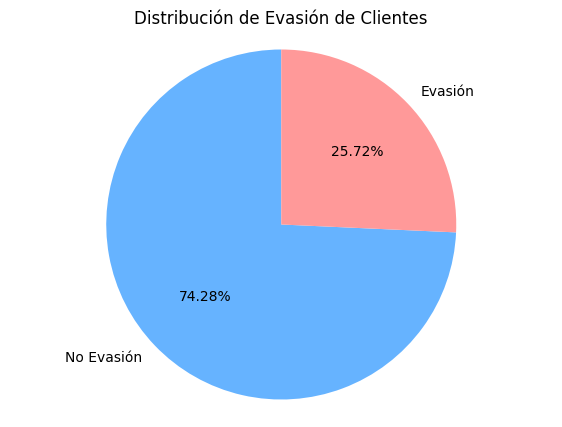

In [82]:
fig, ax = plt.subplots(figsize=(7,5))

etiquetas = ['No Evasión', 'Evasión']
#tamaños = [evasion[0], evasion[1]]  Esta opcion devuelve los conteos de los indices del pandas Series
colores = ['#66b3ff','#ff9999']

ax.pie(evasion.values, labels=etiquetas, autopct='%1.2f%%', startangle=90, colors=colores)
ax.axis('equal') # Una relación de aspecto equal asegura que el gráfico se dibujecomo un circulo

plt.title('Distribución de Evasión de Clientes')
plt.show()

##Recuento de evasión por variables categóricas

In [83]:
datos_clientes_norm.head(1)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19


Vamos a explorar un poco los datos para conocer cuáles son las variables categóricas más relevantes para el análisis. Empezaremos por algo sencillo, como contar la columna Genero

In [84]:
datos_clientes_norm['Genero'].value_counts()

,count
Genero,
Male,3675
Female,3592


No hay una diferencia significativa entre ambos géneros, probemos entonces con una agrupación para saber si hay más presencia de alguno de los dos en las columas `Tipo_De_Contrato` y `Metodo_De_Pago`. Vamos a desapilar también la columna Genero usando unstack() para tener una mejor visualización.

In [85]:
datos_clientes_norm.groupby(['Tipo_De_Contrato','Metodo_De_Pago', ])['Genero'].value_counts().unstack(level='Genero')


Genero                                      Female  Male
Tipo_De_Contrato Metodo_De_Pago                         
Month-to-month   Bank transfer (automatic)     320   288
                 Credit card (automatic)       276   281
                 Electronic check              955   960
                 Mailed check                  431   494
One year         Bank transfer (automatic)     199   202
                 Credit card (automatic)       205   208
                 Electronic check              167   192
                 Mailed check                  169   177
Two year         Bank transfer (automatic)     294   286
                 Credit card (automatic)       293   305
                 Electronic check               83    88
                 Mailed check                  200   194

Observemos que en Tipo_De_contrato "Month-to-month" (mes a mes) y Metodo_De_Pago "Electronic check" tenemos una cantidad significativa de Male y Female (Masculino y Femenino), por lo que estas dos columnas podrían ser determinantes en nuestro análisis.

Realicemos ahora una agrupación incluyendo las columnas anteriores, contando finalmente la evasión por cada combinación de estas categorias

In [86]:
evasion_por_categorias = datos_clientes_norm.groupby(['Genero', 'Tipo_De_Contrato', 'Metodo_De_Pago'])['Retirado'].value_counts()
evasion_por_categorias

Genero  Tipo_De_Contrato  Metodo_De_Pago             Retirado
Female  Month-to-month    Bank transfer (automatic)  0           208
                                                     1           112
                          Credit card (automatic)    0           173
                                                     1           103
                          Electronic check           1           492
                                                     0           463
                          Mailed check               0           296
                                                     1           135
        One year          Bank transfer (automatic)  0           182
                                                     1            17
                          Credit card (automatic)    0           183
                                                     1            22
                          Electronic check           0           144
                                                     1            23
                          Mailed check               0           156
                                                     1            13
        Two year          Bank transfer (automatic)  0           287
                                                     1             7
                          Credit card (automatic)    0           287
                                                     1             6
                          Electronic check           0            76
                                                     1             7
                          Mailed check               0           198
                                                     1             2
Male    Month-to-month    Bank transfer (automatic)  0           199
                                                     1            89
                          Credit card (automatic)    0           206
                                                     1            75
                          Electronic check           1           502
                                                     0           458
                          Mailed check               0           347
                                                     1           147
        One year          Bank transfer (automatic)  0           181
                                                     1            21
                          Credit card (automatic)    0           189
                                                     1            19
                          Electronic check           0           151
                                                     1            41
                          Mailed check               0           167
                                                     1            10
        Two year          Bank transfer (automatic)  0           274
                                                     1            12
                          Credit card (automatic)    0           298
                                                     1             7
                          Electronic check           0            82
                                                     1             6
                          Mailed check               0           193
                                                     1             1
Name: count, dtype: int64



###Pasos a seguir

1. Transformar la serie `evasion_por_categorias` en un DataFrame.
2. Reorganizar el nivel de índice 'Retirado' para crear columnas separadas para los conteos de 'No Evasión' (0) y 'Evasión' (1).
3. Calcular la tasa de evasión (porcentaje de 'Retirado' = 1) para cada combinación de 'Genero', 'Tipo_De_Contrato' y 'Metodo_De_Pago'.
4. Crear un gráfico de barras para visualizar las tasas de evasión, enfocándose en las variables categóricas clave y asegurando etiquetas y leyendas claras.
5. Proporcionar un resumen de las principales observaciones y patrones del análisis.

####Transformar la serie evasion_por_categorias en un dataFrame y desapilar la columna "Retirado"






In [87]:
df_evasion_por_categorias = evasion_por_categorias.unstack(level='Retirado')
df_evasion_por_categorias = df_evasion_por_categorias.reset_index()
df_evasion_por_categorias

Retirado,Genero,Tipo_De_Contrato,Metodo_De_Pago,0,1
0,Female,Month-to-month,Bank transfer (automatic),208,112
1,Female,Month-to-month,Credit card (automatic),173,103
2,Female,Month-to-month,Electronic check,463,492
3,Female,Month-to-month,Mailed check,296,135
4,Female,One year,Bank transfer (automatic),182,17
5,Female,One year,Credit card (automatic),183,22
6,Female,One year,Electronic check,144,23
7,Female,One year,Mailed check,156,13
8,Female,Two year,Bank transfer (automatic),287,7
9,Female,Two year,Credit card (automatic),287,6


Vamos a llamar al método info() para asegurarnos de que los tipos de datos sean correctos y no hayan valores nulos

In [88]:
df_evasion_por_categorias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Genero            24 non-null     object
 1   Tipo_De_Contrato  24 non-null     object
 2   Metodo_De_Pago    24 non-null     object
 3   0                 24 non-null     int64 
 4   1                 24 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 1.1+ KB


Ahora calculamos la tasa de evasión (1) creando una nueva columna llamada Tasa_de_Evasion. También notamos que en ciertas combinaciones no hubieron retirados, por lo tanto de nuestro dataFrame df_evasion_por_categorias obtuvimos algunos NaN en la columna (1) que debemos manejar reemplazandolos por 0 (cero)

In [89]:
df_evasion_por_categorias = df_evasion_por_categorias.fillna(0)
df_evasion_por_categorias['Tasa_de_Evasion'] = (df_evasion_por_categorias[1] / (df_evasion_por_categorias[0] + df_evasion_por_categorias[1])) * 100
df_evasion_por_categorias.head()

Retirado,Genero,Tipo_De_Contrato,Metodo_De_Pago,0,1,Tasa_de_Evasion
0,Female,Month-to-month,Bank transfer (automatic),208,112,35.000000
1,Female,Month-to-month,Credit card (automatic),173,103,37.318841
2,Female,Month-to-month,Electronic check,463,492,51.518325
3,Female,Month-to-month,Mailed check,296,135,31.322506
4,Female,One year,Bank transfer (automatic),182,17,8.542714


#### Visualizar Tasas de Evasión






El siguiente paso es visualizar las tasas de evasión calculadas. Utilizaremos seaborn.barplot para crear un gráfico de barras, representando 'Tipo_De_Contrato' en el eje x, 'Tasa_de_Evasion' en el eje y, y usando 'Metodo_De_Pago' como un matiz para diferenciar las barras. Esto ayudará a identificar patrones de deserción según el tipo de contrato y el método de pago.


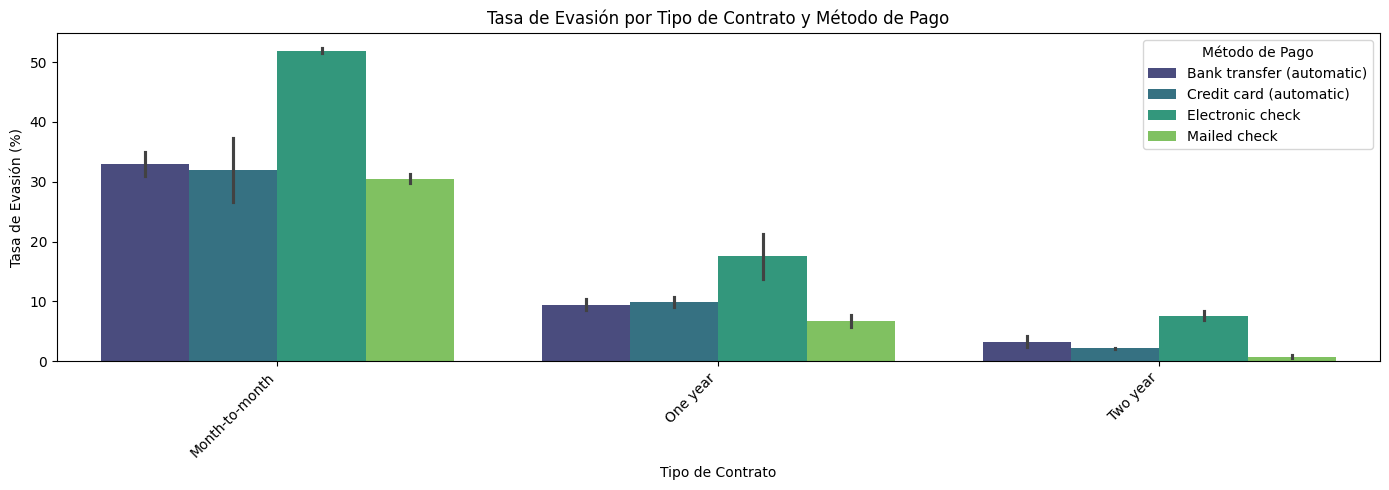

In [90]:
import seaborn as sns


plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_evasion_por_categorias,
    x='Tipo_De_Contrato',
    y='Tasa_de_Evasion',
    hue='Metodo_De_Pago',
    palette='viridis'
)
plt.title('Tasa de Evasión por Tipo de Contrato y Método de Pago')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Evasión (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de Pago')
plt.tight_layout()
plt.show()

#### Observaciones de la Tasa de Evasión por Tipo de Contrato y Método de Pago

El gráfico de barras muestra la tasa de evasión de clientes (`Retirado` = 1) para diferentes combinaciones de `Tipo_De_Contrato` y `Metodo_De_Pago`.

### Patrones Observados:

*   **Contrato Mes a Mes (Month-to-month):** Se observa consistentemente que los clientes con contratos mes a mes tienen una tasa de evasión significativamente más alta en comparación con otros tipos de contrato, independientemente del método de pago. Esto sugiere que la falta de un compromiso a largo plazo es un factor clave en la evasión.

*   **Método de Pago 'Electronic check':** Para los contratos mes a mes, el método de pago 'Electronic check' (cheque electrónico) muestra una de las tasas de evasión más altas. Esto podría indicar que los clientes que utilizan este método de pago en contratos cortos son más propensos a cancelar el servicio.

*   **Contratos de Uno y Dos Años (One year y Two year):** Los clientes con contratos de uno y dos años presentan tasas de evasión considerablemente más bajas en todas las categorías de métodos de pago. Esto refuerza la idea de que los contratos a largo plazo fomentan la lealtad y reducen la probabilidad de evasión.

*   **Métodos de Pago 'Bank transfer (automatic)' y 'Credit card (automatic)':** Estos métodos de pago tienden a tener tasas de evasión más bajas en general, especialmente en contratos de mayor duración, lo que sugiere una mayor estabilidad y menor probabilidad de cancelación por parte de los clientes que los utilizan.

*   **'Mailed check' (Cheque por correo):** Este método de pago muestra una tasa de evasión moderada, siendo más alta en contratos mes a mes y disminuyendo con contratos más largos.

### Conclusiones Preliminares:

1.  **Tipo de Contrato:** El tipo de contrato es un predictor muy fuerte de la evasión, siendo los contratos 'Month-to-month' los de mayor riesgo.
2.  **Método de Pago:** Dentro de los contratos a corto plazo, el 'Electronic check' es un método de pago asociado a una mayor evasión.
3.  **Lealtad:** Los clientes con contratos a largo plazo y aquellos que utilizan métodos de pago automáticos (transferencia bancaria o tarjeta de crédito) son los más estables y menos propensos a la evasión.

En resumen, la **duración del contrato** es el principal motor de la evasión, con los contratos mes a mes siendo un punto crítico. El **método de pago** es un factor secundario importante, especialmente en los contratos más cortos, donde 'Electronic check' indica un mayor riesgo.

##Conteo de evasión por variables numéricas

In [91]:
datos_clientes_norm.head(1)

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Del_Dispositivo,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19


In [92]:
datos_clientes_norm.groupby('Tipo_De_Contrato')['Total_Por_Mes'].mean()

,Total_Por_Mes
Tipo_De_Contrato,
Month-to-month,66.344594
One year,65.233344
Two year,60.540103


In [93]:
len(datos_clientes_norm['Meses_De_Contrato'].unique())

73

In [94]:
evasion_numericas = datos_clientes_norm.groupby(['Meses_De_Contrato', 'Total_Gastado'])['Retirado'].value_counts().unstack(level='Retirado')
evasion_numericas.columns.name = None
evasion_numericas.head()

0    1
Meses_De_Contrato Total_Gastado           
0                 0.00           11.0  NaN
1                 18.80           1.0  NaN
                  18.85           1.0  1.0
                  18.90           2.0  NaN
                  19.00           1.0  NaN

In [95]:
df_evasion_numericas = evasion_numericas.reset_index()
df_evasion_numericas.head(1)

,Meses_De_Contrato,Total_Gastado,0,1
0,0,0.0,11.0,NaN


In [96]:
df_evasion_numericas.isna().sum()

,0
Meses_De_Contrato,0
Total_Gastado,0
0,1616
1,4997


In [99]:
df_evasion_numericas = df_evasion_numericas.fillna(0)
df_evasion_numericas

,Meses_De_Contrato,Total_Gastado,0,1
0,0,0.00,11.0,0.0
1,1,18.80,1.0,0.0
2,1,18.85,1.0,1.0
3,1,18.90,2.0,0.0
4,1,19.00,1.0,0.0
...,...,...,...,...
6749,72,8547.15,1.0,0.0
6750,72,8594.40,1.0,0.0
6751,72,8670.10,1.0,0.0
6752,72,8672.45,1.0,0.0


El dataFrame obtenido `df_evasion_numericas`  nos muestra que la relación entre Meses_De_Contrato y Total_Gastado es directamente proporcional, pero debido a que la cantidad de valores únicos en la columna Total_Gastado (6754) es muy similar a la muestra total (7267), será muy difícil encontrar una tendencia de evasión con los datos presentados de esta forma, por lo que vamos a crear rangos para estas dos columnas, siendo ('Corto Plazo', 'Mediano Plazo', 'Largo Plazo') para la columna Meses_De_Contrato y ('Gasto Bajo', 'Gasto Medio', 'Gasto Alto') para Total_Gastado y asi poder tener una mejor visualización de los resultado obtenidos.

### Definir y Aplicar Rangos para Meses_De_Contrato y Total_Gastado



Crearemos categorías (bins) para la columna 'Meses_De_Contrato' en el DataFrame `datos_clientes_norm` para agrupar los clientes por su antigüedad en el contrato ('Corto Plazo', 'Mediano Plazo', 'Largo Plazo').


In [105]:
bins = [0, 24, 48, 72]
labels = ['Corto Plazo', 'Mediano Plazo', 'Largo Plazo']

datos_clientes_norm['Antiguedad_Contrato_Bins'] = pd.cut(datos_clientes_norm['Meses_De_Contrato'], bins=bins, labels=labels, right=True, include_lowest=True)

datos_clientes_norm.head()

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Soporte_Tecnico,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias,Antiguedad_Contrato_Bins
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,Corto Plazo
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,Corto Plazo
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,Corto Plazo
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,Corto Plazo
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,Corto Plazo


Crearemos categorías (bins) para la columna 'Total_Gastado' en el DataFrame `datos_clientes_norm` para clasificar los gastos segun el valor en ('Gasto Bajo', 'Gasto Medio', 'Gasto Alto').



In [106]:
bins_gasto = [0, 1000, 4000, datos_clientes_norm['Total_Gastado'].max()]
labels_gasto = ['Gasto Bajo', 'Gasto Medio', 'Gasto Alto']

datos_clientes_norm['Total_Gastado_Bins'] = pd.cut(datos_clientes_norm['Total_Gastado'], bins=bins_gasto, labels=labels_gasto, right=True, include_lowest=True)

datos_clientes_norm.head()

,ID_Cliente,Retirado,Genero,Mayor_65_Años,Tiene_Pareja,Dependientes,Meses_De_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Television_Por_Cable,Streaming_Peliculas,Tipo_De_Contrato,Factura_En_Linea,Metodo_De_Pago,Total_Por_Mes,Total_Gastado,Cuentas_Diarias,Antiguedad_Contrato_Bins,Total_Gastado_Bins
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,One year,1,Mailed check,65.6,593.30,2.19,Corto Plazo,Gasto Bajo
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,Corto Plazo,Gasto Bajo
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,Corto Plazo,Gasto Bajo
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,Corto Plazo,Gasto Medio
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,Corto Plazo,Gasto Bajo


Ahora realizamos una agrupación por las columnas 'Antiguedad_Contrato_Bins'y 'Total_Gastado_Bins', usamos la función value_counts() en la columna 'Retirado' y desapilamos con unstack().

Adicionalmente, creamos una columna llamada 'Tasa_De_Evasion' para calcular la tasa de evasión por cada combinacion

Aplicamos reset_index() para convertir la Series en un DataFrame

In [107]:
evasion_bins = datos_clientes_norm.groupby(['Antiguedad_Contrato_Bins', 'Total_Gastado_Bins'])['Retirado'].value_counts().unstack(fill_value=0)
evasion_bins['Tasa_De_Evasion'] = (evasion_bins[1] / (evasion_bins[0] + evasion_bins[1])) * 100
evasion_bins.reset_index(inplace=True)
evasion_bins

/tmp/ipython-input-2340460500.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evasion_bins = datos_clientes_norm.groupby(['Antiguedad_Contrato_Bins', 'Total_Gastado_Bins'])['Retirado'].value_counts().unstack(fill_value=0)


Retirado,Antiguedad_Contrato_Bins,Total_Gastado_Bins,0,1,Tasa_De_Evasion
0,Corto Plazo,Gasto Bajo,1593,1059,39.932127
1,Corto Plazo,Gasto Medio,386,272,41.337386
2,Corto Plazo,Gasto Alto,0,0,NaN
3,Mediano Plazo,Gasto Bajo,323,11,3.293413
4,Mediano Plazo,Gasto Medio,875,253,22.429078
5,Mediano Plazo,Gasto Alto,125,61,32.795699
6,Largo Plazo,Gasto Bajo,18,0,0.000000
7,Largo Plazo,Gasto Medio,747,31,3.984576
8,Largo Plazo,Gasto Alto,1331,182,12.029081


Reemplazamoslos valores nulos por 0 (Cero) y creamos el gráfico de barras

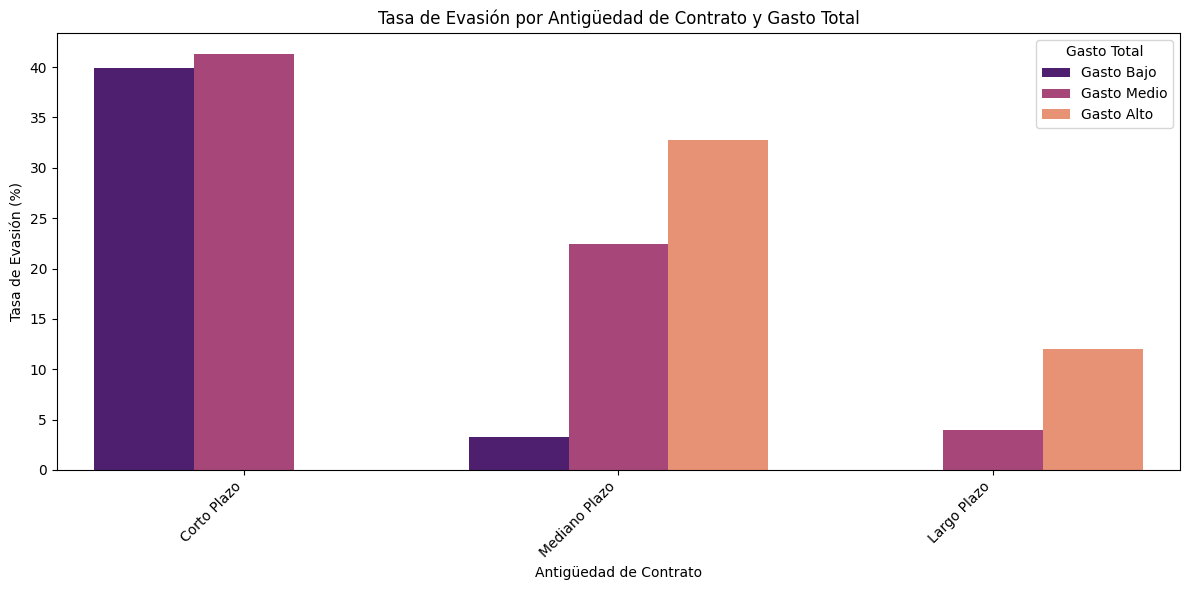

In [108]:
evasion_bins['Tasa_De_Evasion'] = evasion_bins['Tasa_De_Evasion'].fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=evasion_bins,
    x='Antiguedad_Contrato_Bins',
    y='Tasa_De_Evasion',
    hue='Total_Gastado_Bins',
    palette='magma'
)
plt.title('Tasa de Evasión por Antigüedad de Contrato y Gasto Total')
plt.xlabel('Antigüedad de Contrato')
plt.ylabel('Tasa de Evasión (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gasto Total')
plt.tight_layout()
plt.show()


#### Observaciones de la Tasa de Evasión por Antigüedad de Contrato y Gasto Total

El gráfico de barras muestra la tasa de evasión (`Retirado` = 1) de clientes segmentados por su antigüedad en el contrato (`Antiguedad_Contrato_Bins`) y su gasto total (`Total_Gastado_Bins`).

### Patrones Observados:

*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Corto Plazo (0-24 meses):** Esta categoría muestra las tasas de evasión más altas en general. Los clientes con 'Gasto Bajo' y 'Gasto Medio' en este rango de antigüedad tienen tasas de evasión cercanas al 40%. Esto sugiere que los clientes nuevos o con poca antigüedad son más propensos a la evasión, especialmente si su gasto no es muy alto.
    *   **Mediano Plazo (25-48 meses):** La tasa de evasión disminuye significativamente en esta categoría. Aunque 'Gasto Bajo' tiene una tasa muy baja (alrededor del 3%), los clientes con 'Gasto Medio' y 'Gasto Alto' muestran tasas de evasión del 22.4% y 32.8% respectivamente. Esto indica que si un cliente de mediano plazo tiene un gasto alto, el riesgo de evasión aumenta, aunque no tan alto como en el corto plazo.
    *   **Largo Plazo (49-72 meses):** Los clientes de largo plazo presentan las tasas de evasión más bajas. Es notable que los clientes con 'Gasto Bajo' en este segmento tienen una tasa de evasión del 0%. Incluso en los segmentos de 'Gasto Medio' y 'Gasto Alto', las tasas son considerablemente menores (alrededor del 4% y 12% respectivamente) en comparación con los contratos de menor duración.

*   **Gasto Total (Total_Gastado_Bins):**
    *   **Gasto Bajo:** En general, los clientes con 'Gasto Bajo' tienen una tasa de evasión alta en los contratos de corto plazo, pero esta tasa disminuye drásticamente a medida que aumenta la antigüedad del contrato, llegando a ser 0% en largo plazo.
    *   **Gasto Medio:** Estos clientes muestran una tasa de evasión considerable en corto y mediano plazo, pero se reduce drásticamente en el largo plazo.
    *   **Gasto Alto:** Los clientes con 'Gasto Alto' también siguen el patrón general de disminución de la evasión con la antigüedad del contrato, aunque su tasa en 'Mediano Plazo' (32.8%) es notablemente alta, casi comparable a la de 'Corto Plazo'. Esto podría ser un segmento de alto valor y alto riesgo en el mediano plazo.

### Conclusiones Preliminares:

1.  **Antigüedad del Contrato como Predictor Principal:** La antigüedad del contrato es un factor determinante en la tasa de evasión. Los clientes en los primeros 24 meses son los más propensos a la evasión.
2.  **Riesgo en Clientes Recientes con Cualquier Nivel de Gasto:** Para los clientes de corto plazo, la tasa de evasión es alta independientemente de su nivel de gasto, aunque es ligeramente mayor para 'Gasto Medio'.
3.  **Estabilidad en Clientes de Largo Plazo:** Los clientes con contratos de larga duración muestran una gran estabilidad, con tasas de evasión muy bajas en todos los niveles de gasto, especialmente en el segmento de 'Gasto Bajo'.
4.  **Segmento de Riesgo en Mediano Plazo:** Clientes de 'Mediano Plazo' con 'Gasto Alto' (32.8%) representan un grupo de interés, ya que su tasa de evasión es mayor que la de 'Gasto Medio' en el mismo período y comparable a algunos segmentos de 'Corto Plazo'. Esto sugiere que, a pesar de haber permanecido por un tiempo considerable, estos clientes de alto gasto pueden ser susceptibles a la evasión si no se mantienen satisfechos.

#📄Informe final

##**Introducción**

El objetivo principal de este análisis es comprender a fondo los factores que influyen en la evasión de clientes, comúnmente conocida como "Churn", en el sector de las telecomunicaciones. A través de este estudio, buscamos identificar patrones y causas subyacentes que llevan a los clientes a cancelar sus servicios, proporcionando así una base sólida para desarrollar estrategias de retención efectivas.

El problema de la evasión de clientes es crítico para las empresas de telecomunicaciones, ya que impacta directamente en sus ingresos y rentabilidad. La pérdida de un cliente no solo significa la interrupción de ingresos recurrentes, sino que también implica costos asociados a la adquisición de nuevos clientes, los cuales suelen ser significativamente más altos que los de retención. Por ello, entender por qué los clientes se van es fundamental para mantener una base de usuarios estable y un crecimiento sostenible.

En el presente informe, se explorarán diversas variables demográficas, de servicio y de contrato para identificar los principales contribuyentes a la evasión. Además, se analizarán los datos históricos para detectar tendencias y se presentarán visualizaciones clave que ilustren los hallazgos. Finalmente, se formularán recomendaciones estratégicas orientadas a mitigar la tasa de Churn y mejorar la lealtad de los clientes.

## Limpieza y Tratamiento de Datos

Esta sección detalla los pasos seguidos para preparar los datos para el análisis, desde la importación inicial hasta la estandarización de formatos y la creación de nuevas variables.

### 1. Importación de Datos

Se inició el proceso importando la librería `pandas`, fundamental para la manipulación de datos en Python. Posteriormente, el archivo `TelecomX_Data.json` fue cargado en un DataFrame denominado `datos_clientes` utilizando `pd.read_json()`. Este DataFrame contenía la información inicial de los clientes en un formato JSON anidado.

### 2. Normalización de Columnas JSON

El DataFrame `datos_clientes` presentaba columnas con estructuras JSON anidadas (`customer`, `phone`, `internet`, `account`). Para aplanarlas y facilitar su manejo, se utilizó la función `pd.json_normalize()` para cada una de estas columnas, creando DataFrames separados (`customer`, `phone`, `internet`, `account`). Finalmente, estas tablas normalizadas se concatenaron horizontalmente (axis=1) con las columnas `customerID` y `Churn` del DataFrame original, resultando en el DataFrame `datos_clientes_norm`, una tabla plana con toda la información relevante de los clientes.

### 3. Verificación y Limpieza Inicial de Datos

Una vez normalizados los datos, se realizó una verificación inicial para identificar posibles problemas:

*   **Tipos de Datos y Valores Nulos:** Se examinó la estructura y los tipos de datos de cada columna con `datos_clientes_norm.info()` y `datos_clientes_norm.dtypes`. Esto permitió identificar la columna `Total_Gastado` como tipo `object`, lo que indicaba la presencia de caracteres no numéricos o inconsistencias que impedían su correcta interpretación como valor numérico. Se confirmó que no había valores nulos en la mayoría de las columnas al revisar los `Non-Null Count`.
*   **Unicidad de `customerID`:** Se verificó que la columna `customerID` contuviera solo valores únicos, asegurando que cada fila representara un cliente distinto. Se comprobó la longitud de los valores únicos (`len(datos_clientes_norm['customerID'].unique())`), la cual coincidió con el número total de filas.
*   **Identificación de Espacios en `Total_Gastado`:** Se detectó la presencia de cadenas de texto vacías (' ') en la columna `Total_Gastado` utilizando `datos_clientes_norm['Total_Gastado'].str.contains('\s', na=False)`. Se observó que estas entradas correspondían a clientes con `Meses_De_Contrato` igual a 0, lo que indicaba que eran clientes nuevos sin un gasto total acumulado aún.

### 4. Tratamiento de `Total_Gastado` y Conversión de Tipos

Para corregir la columna `Total_Gastado`, se realizaron los siguientes pasos:

*   **Reemplazo de Espacios:** Las cadenas vacías (' ') en `Total_Gastado` se reemplazaron por '0' utilizando el método `.replace()`, lo que permitía interpretar correctamente a los clientes nuevos como aquellos con 0 gasto total.
*   **Conversión a Numérico:** Una vez que `Total_Gastado` solo contenía caracteres numéricos (o '0'), se convirtió su tipo de dato a `float64` utilizando `astype(np.float64)`, permitiendo operaciones matemáticas con esta columna.

### 5. Normalización y Conversión de Columnas Categóricas a Numéricas

Varias columnas categóricas (`Retirado`, `Tiene_Pareja`, `Dependientes`, `Servicio_Telefonico`, `Multiples_Lineas`, `Seguridad_En_linea`, `Respaldo_En_linea`, `Proteccion_Del_Dispositivo`, `Soporte_Tecnico`, `Television_Por_Cable`, `Streaming_Peliculas`, `Factura_En_Linea`) contenían valores 'Yes'/'No' o frases como 'No phone service' y 'No internet service'. Para facilitar el análisis cuantitativo, se transformaron de la siguiente manera:

*   **Mapeo de Valores:** Se creó un diccionario de reemplazo para convertir 'Yes' a '1' y 'No' a '0'. Además, 'No phone service' y 'No internet service' también se mapearon a '0' para representar la ausencia del servicio o característica.
*   **Aplicación del Reemplazo:** Se aplicó este mapeo a todas las columnas seleccionadas utilizando un bucle `for` y el método `.replace()`.
*   **Conversión a `int64`:** Finalmente, todas estas columnas fueron convertidas al tipo `int64` para representarlas como variables binarias numéricas (0 o 1).

### 6. Renombrado de Columnas

Para mejorar la claridad y el manejo del DataFrame, se renombraron todas las columnas con nombres más descriptivos y en español, utilizando un diccionario de mapeo (`renombrar`) y el método `datos_clientes_norm.rename(columns=renombrar, inplace=True)`.

### 7. Creación de Nueva Columna `Cuentas_Diarias`

Como parte de la ingeniería de características, se creó una nueva columna llamada `Cuentas_Diarias`, calculada dividiendo el `Total_Por_Mes` entre 30 y redondeando el resultado a dos decimales. Esto proporciona una métrica de gasto promedio diario por cliente.

## Informe Final del Análisis de Evasión de Clientes

Este informe resume los hallazgos clave del análisis exploratorio de datos (EDA) sobre la evasión de clientes, destacando los factores más influyentes a través de las visualizaciones generadas.

### 1. Distribución General de la Evasión

El análisis inicial de la columna 'Retirado' (Churn) reveló la distribución general de la evasión de clientes. El gráfico de pastel (`dXRmp-yPmHAb`) mostró que una proporción significativa de clientes ha evadido el servicio. Específicamente, **el 25.72% de los clientes han evadido**, mientras que el **74.28% han permanecido**. Esta distribución resalta la importancia de entender los factores que contribuyen a esta tasa de evasión para implementar estrategias de retención efectivas.

### 2. Análisis de Evasión por Variables Categóricas

La exploración de variables categóricas, como 'Tipo_De_Contrato' y 'Metodo_De_Pago', proporcionó información crucial sobre los segmentos de clientes más propensos a la evasión. El gráfico de barras (`ceb3e595`) para la 'Tasa de Evasión por Tipo de Contrato y Método de Pago' reveló lo siguiente:

*   **Tipo de Contrato:** Los clientes con **contratos mes a mes (`Month-to-month`) muestran consistentemente las tasas de evasión más altas**. Esto sugiere que la falta de un compromiso a largo plazo es un factor de riesgo primordial. En contraste, los contratos de uno y dos años presentan tasas de evasión significativamente más bajas, indicando que la lealtad del cliente aumenta con la duración del compromiso contractual.
*   **Método de Pago:** Dentro de los contratos mes a mes, el **método de pago 'Electronic check' (cheque electrónico) está asociado con una de las tasas de evasión más elevadas**. Esto podría indicar una mayor facilidad para cancelar el servicio o una menor fricción en el proceso de baja para estos clientes. Métodos de pago automáticos como 'Bank transfer (automatic)' y 'Credit card (automatic)' generalmente muestran tasas de evasión más bajas, especialmente en contratos de mayor duración, sugiriendo una mayor estabilidad del cliente.

### 3. Análisis de Evasión por Variables Numéricas

Para comprender la influencia de las variables numéricas 'Meses_De_Contrato' y 'Total_Gastado' en la evasión, se crearon categorías (`bins`) para cada una: 'Antiguedad_Contrato_Bins' ('Corto Plazo', 'Mediano Plazo', 'Largo Plazo') y 'Total_Gastado_Bins' ('Gasto Bajo', 'Gasto Medio', 'Gasto Alto'). El gráfico de barras (`f6b6c852`) de 'Tasa de Evasión por Antigüedad de Contrato y Gasto Total' reveló:

*   **Antigüedad del Contrato:** Los clientes en la categoría de **'Corto Plazo' (0-24 meses) exhiben las tasas de evasión más altas**, independientemente de su nivel de gasto. Esto refuerza la observación anterior sobre los contratos mes a mes, ya que muchos clientes de corto plazo probablemente tienen este tipo de contrato. La tasa de evasión disminuye drásticamente a medida que la antigüedad del contrato aumenta, siendo los clientes de 'Largo Plazo' (49-72 meses) los más estables, incluso con un 0% de evasión en el segmento de 'Gasto Bajo'.
*   **Gasto Total:** Si bien los clientes de 'Corto Plazo' con 'Gasto Bajo' tienen una alta tasa de evasión, esta disminuye significativamente para 'Gasto Bajo' en 'Mediano' y 'Largo Plazo'. Es notable que los clientes de **'Mediano Plazo' con 'Gasto Alto' presentan una tasa de evasión considerable (32.8%)**, comparable a algunos segmentos de 'Corto Plazo'. Esto sugiere que, a pesar de su antigüedad y alto gasto, este grupo podría ser un segmento de alto valor y alto riesgo que requiere atención específica.

### Conclusiones y Hallazgos Clave:

1.  **Antigüedad del Contrato:** Es el factor más determinante. Los clientes nuevos o con poca antigüedad (menos de 24 meses) y los que tienen contratos mes a mes son los más propensos a la evasión.
2.  **Método de Pago:** El 'Electronic check' es un método de pago asociado con un mayor riesgo de evasión, especialmente para los contratos a corto plazo.
3.  **Segmentos de Riesgo:** Se identifican dos segmentos de alto riesgo:
    *   Clientes de 'Corto Plazo' (0-24 meses), especialmente aquellos con contratos mes a mes y método de pago 'Electronic check'.
    *   Clientes de 'Mediano Plazo' (25-48 meses) con 'Gasto Alto', quienes, a pesar de su mayor antigüedad, muestran una tasa de evasión notablemente alta.
4.  **Estabilidad:** Los clientes con contratos de larga duración y aquellos que utilizan métodos de pago automáticos (transferencia bancaria o tarjeta de crédito) son los más estables y menos propensos a la evasión.

### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):**
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.

### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasióen asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.

### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasióen asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.

### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasióen asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:**
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):**
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


### Conclusiones e Insights Clave del Análisis de Evasión

El análisis exploratorio de datos ha revelado varios patrones significativos y relaciones que son cruciales para comprender y mitigar la evasión de clientes. A continuación, se resumen los principales hallazgos y su utilidad práctica:

#### 1. Distribución General de la Evasión:
*   **Observación:** Aproximadamente el 25.7% de los clientes han evadido el servicio, lo que indica un problema considerable que requiere atención.
*   **Utilidad:** Esta cifra inicial establece la magnitud del desafío y sirve como una línea base para medir el éxito de futuras estrategias de retención.

#### 2. Factores Clave Derivados de Variables Categóricas:
*   **Tipo de Contrato:**
    *   **Observación:** Los clientes con **contratos mes a mes** (`Month-to-month`) presentan las tasas de evasión más elevadas. En contraste, los contratos de uno y dos años muestran tasas de evasión considerablemente más bajas.
    *   **Utilidad:** Esto subraya la importancia de fomentar contratos a largo plazo. Las estrategias de marketing y ventas deben enfocarse en incentivar la migración de clientes a planes anuales o bienales, quizás ofreciendo descuentos o beneficios adicionales por comprometerse a una mayor duración.
*   **Método de Pago:
    *   **Observación:** El método de pago `Electronic check` (cheque electrónico) está fuertemente asociado con altas tasas de evasión, especialmente en contratos mes a mes. Otros métodos de pago como `Bank transfer (automatic)` y `Credit card (automatic)` demuestran mayor estabilidad.
    *   **Utilidad:** La empresa debería investigar las razones detrás de la alta evasión con cheques electrónicos. Podría ser que este método atraiga a clientes menos comprometidos o que experimenten problemas específicos con el servicio que los llevan a una cancelación rápida. Se podrían diseñar campañas para promover métodos de pago automáticos, que sugieren un mayor compromiso del cliente.

#### 3. Factores Clave Derivados de Variables Numéricas (Binned):
*   **Antigüedad del Contrato (Meses_De_Contrato):
    *   **Observación:** La tasa de evasión es notablemente alta en los clientes de **Corto Plazo** (0-24 meses), disminuyendo progresivamente en los de Mediano Plazo (25-48 meses) y siendo mínima en los de Largo Plazo (49-72 meses).
    *   **Utilidad:** Los primeros 24 meses son críticos para la retención de clientes. La empresa debe implementar programas de onboarding robustos, seguimiento proactivo y ofertas personalizadas durante este período para garantizar una experiencia positiva y fomentar la lealtad. Identificar y abordar posibles puntos de fricción tempranamente es fundamental.
*   **Gasto Total (Total_Gastado):
    *   **Observación:** Aunque el 'Gasto Bajo' en el corto plazo muestra una alta evasión, es interesante que los clientes de 'Mediano Plazo' con 'Gasto Alto' también presentan una tasa de evasión considerable (alrededor del 32.8%). En el largo plazo, todas las categorías de gasto tienen bajas tasas de evasión.
    *   **Utilidad:** Los clientes de alto gasto en el mediano plazo representan un segmento de alto valor y alto riesgo. La empresa debe diseñar estrategias de retención específicas para este grupo, asegurándose de que su experiencia justifique su inversión y reduzca la probabilidad de que busquen alternativas. Para los clientes de bajo gasto en el corto plazo, se podría explorar si el problema radica en la adecuación del servicio a sus necesidades o en una mala experiencia inicial.

#### Implicaciones para la Reducción de la Evasión:

El análisis sugiere que la duración del contrato y la antigüedad del cliente son los predictores más fuertes de la evasión. Los clientes recientes y aquellos con contratos flexibles (mes a mes) son los más vulnerables. El método de pago, especialmente el `Electronic check`, es un factor de riesgo adicional, particularmente en el segmento de contratos a corto plazo.

Para reducir la evasión, la empresa debería:

1.  **Fomentar la Lealtad a Largo Plazo:** Implementar incentivos atractivos para que los clientes opten por contratos de mayor duración desde el inicio o durante las renovaciones.
2.  **Optimizar la Experiencia del Cliente Temprana:** Fortalecer los programas de bienvenida y soporte para nuevos clientes, especialmente durante los primeros 24 meses, para asegurar una alta satisfacción y reducir la probabilidad de una evasión temprana.
3.  **Evaluar Métodos de Pago:** Investigar las causas subyacentes de la alta evasión asociada con el `Electronic check` y, si es posible, guiar a los clientes hacia métodos de pago más estables.
4.  **Monitorear Segmentos de Alto Riesgo:** Prestar especial atención a los clientes con contratos mes a mes y a los clientes de mediano plazo con alto gasto, ya que estos grupos han demostrado ser más propensos a la evasión.


## Generar Sección de Recomendaciones

### Subtask:
Ofrecer sugerencias estratégicas y accionables basadas en las conclusiones obtenidas del análisis, orientadas a mitigar la evasión de clientes.


## Recomendaciones Estratégicas para Mitigar la Evasión de Clientes

Basándonos en las conclusiones obtenidas del análisis de evasión de clientes, se proponen las siguientes sugerencias estratégicas para mitigar la deserción y fomentar la lealtad:

### 1. Fomento de la Lealtad a Largo Plazo

**Observación Clave:** Los clientes con contratos de uno y dos años presentan tasas de evasión significativamente más bajas que los clientes con contratos mes a mes. La antigüedad del contrato es un predictor muy fuerte de la evasión, con clientes de largo plazo mostrando gran estabilidad.

**Acciones Estratégicas:**
*   **Ofrecer incentivos para contratos de mayor duración:** Implementar programas de descuento, mejoras en el servicio o beneficios adicionales para los clientes que opten por contratos de uno o dos años al momento de la suscripción o durante la renovación de contratos mensuales.
*   **Comunicación de valor a largo plazo:** Destacar los beneficios y ahorros de los contratos a largo plazo a través de campañas de marketing y comunicación dirigidas a clientes de contrato mensual.
*   **Programas de fidelización:** Crear programas de puntos o recompensas que aumenten con la antigüedad del cliente, incentivando la permanencia.

### 2. Optimización de la Experiencia Temprana del Cliente

**Observación Clave:** Los clientes en los primeros 24 meses de contrato (Corto Plazo) tienen las tasas de evasión más altas, independientemente de su nivel de gasto.

**Acciones Estratégicas:**
*   **Programa de bienvenida y onboarding:** Desarrollar un programa robusto para los nuevos clientes (primeros 3-6 meses) que incluya seguimiento proactivo, tutoriales sobre el uso de los servicios, canales de soporte accesibles y encuestas de satisfacción temprana para identificar y resolver problemas antes de que escalen.
*   **Monitoreo intensivo de la satisfacción:** Realizar encuestas de satisfacción y llamadas de seguimiento a clientes en sus primeros meses para detectar señales de insatisfacción y actuar rápidamente.
*   **Ofertas personalizadas para clientes de corto plazo:** Evaluar la posibilidad de ofrecer adaptaciones en el servicio o precios a clientes de corto plazo que muestren signos de insatisfacción o que estén cerca de la ventana de alta evasión.

### 3. Evaluación de Métodos de Pago

**Observación Clave:** El método de pago 'Electronic check' está asociado con una de las tasas de evasión más altas, especialmente en contratos mes a mes. Por otro lado, los métodos automáticos como 'Bank transfer (automatic)' y 'Credit card (automatic)' muestran tasas de evasión más bajas.

**Acciones Estratégicas:**
*   **Promocionar métodos de pago automáticos:** Incentivar a los clientes a utilizar transferencias bancarias o tarjetas de crédito automáticas ofreciendo pequeños descuentos o beneficios. Estos métodos sugieren una mayor estabilidad del cliente.
*   **Investigar problemas con 'Electronic check':** Realizar un análisis más profundo para entender las razones detrás de la alta evasión asociada con el método de 'Electronic check'. Podría haber problemas de usabilidad, confianza o procesos de pago que contribuyan a la insatisfacción.
*   **Facilitar el cambio de método de pago:** Hacer que el proceso de cambio a un método de pago más estable sea sencillo y accesible para los clientes actuales.

### 4. Monitoreo de Segmentos de Alto Riesgo

**Observación Clave:** El segmento de 'Mediano Plazo' (25-48 meses) con 'Gasto Alto' (Tasa de Evasión del 32.8%) es un grupo de interés, ya que su tasa de evasión es considerable y comparable a algunos segmentos de corto plazo. Este es un grupo de alto valor y alto riesgo.

**Acciones Estratégicas:**
*   **Identificación y segmentación proactiva:** Utilizar modelos predictivos para identificar clientes en los segmentos de alto riesgo (ej. contrato mes a mes, uso de cheque electrónico, clientes de mediano plazo con alto gasto) antes de que tomen la decisión de evadir.
*   **Intervenciones dirigidas:** Desarrollar estrategias de retención específicas para estos segmentos. Por ejemplo, para los clientes de mediano plazo con alto gasto, se podrían ofrecer servicios premium, soporte dedicado, o revisar sus contratos para asegurar que siguen siendo competitivos y satisfacen sus necesidades.
*   **Alertas tempranas:** Implementar un sistema de alerta que notifique a los equipos de atención al cliente sobre clientes que presenten características de alto riesgo, permitiendo una intervención personalizada y a tiempo.

## Tarea Final

### Subtask:
Completar el informe final consolidando todas las secciones generadas.


## Summary:

### Data Analysis Key Findings

*   **Overall Churn Rate**: Approximately 25.72% of customers in the telecom sector have churned, indicating a significant retention challenge.
*   **Data Preparation**: The initial JSON data was normalized, and several cleaning steps were performed, including replacing empty strings in `Total_Gastado` with '0' and converting it to a numeric type, and transforming multiple categorical 'Yes'/'No' columns into binary (0/1) integers. A new feature, `Cuentas_Diarias` (daily expenses), was also engineered.
*   **Contract Type and Churn**: Customers with month-to-month contracts exhibit the highest churn rates, while those with one or two-year contracts show significantly lower rates.
*   **Payment Method and Churn**: The 'Electronic check' payment method is strongly associated with higher churn, particularly among customers with month-to-month contracts. Conversely, automatic payment methods (bank transfers, credit cards) correlate with greater customer stability.
*   **Customer Tenure and Churn**: The first 0-24 months of a customer's contract (Short Term) represent the period with the highest churn rates, which decrease considerably as tenure increases.
*   **Spending Level and Churn Risk**: While low-spending customers in the short term are prone to churn, a notable finding is that high-spending customers in the medium-term (25-48 months) also present a considerable churn rate of 32.8%, identifying them as a high-value, high-risk segment.

### Insights or Next Steps

*   **Prioritize Early Customer Experience and Long-Term Commitments**: The initial 24 months of a customer's journey are critical. Implement robust onboarding programs and incentives to encourage longer contract durations from the start or during early renewal phases to foster loyalty and reduce churn.
*   **Investigate and Mitigate Risks Associated with 'Electronic Check' and High-Value, Medium-Term Customers**: Conduct further analysis into the reasons behind high churn rates for customers using 'Electronic check' and develop targeted retention strategies, potentially offering premium services or dedicated support, for high-spending customers in the 25-48 month tenure bracket.
